In [1]:
import json
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

In [2]:
data_master = []
for temp in ["0_0","0_4","0_8","1_2"]:
    #empty json object
    data_list = {}
    for i in range(4):
        start = str(i * 10 + 1)
        end = str((i + 1) * 10)
        path = f'results/full_run_4/simulation_results_groups_{start}_{end}_{temp}.json'
        with open(path, 'r') as f:
            data = json.load(f)
            data_list.update(data)
    data_master.append(data_list)

In [3]:
with open('simulation_resources/participant_attitudes.json', 'r') as f:
    participants = json.load(f)

groups = list(set([int(x.split("_")[1]) for x in data_master[0].keys()]))
questions = list(set([(x.split("_")[2]) for x in data_master[0].keys()]))

In [4]:
df = []
for participant in participants:
    pid = participant['id']
    groupid = participant['group']
    if groupid in groups:
        for question in questions:
            row = {}
            row['id'] = pid
            row["question"] = question
            row["before_attitude"] = participant['questions'][question]
            groupIndex = "Group_" + str(groupid) + "_" + question
            row["temp_0"] = data_master[0][groupIndex]['rankings'][str(pid)]
            row["temp_4"] = data_master[1][groupIndex]['rankings'][str(pid)]
            row["temp_8"] = data_master[2][groupIndex]['rankings'][str(pid)]
            row["temp_12"] = data_master[3][groupIndex]['rankings'][str(pid)]
            row["temp_0_arguments"] = data_master[0][groupIndex]['arguments'][str(pid)]
            row["temp_4_arguments"] = data_master[1][groupIndex]['arguments'][str(pid)]
            row["temp_8_arguments"] = data_master[2][groupIndex]['arguments'][str(pid)]
            row["temp_12_arguments"] = data_master[2][groupIndex]['arguments'][str(pid)]
            df.append(row)

df = pd.DataFrame(df)

In [5]:
question_df = pd.read_csv("clean_data/question_level_master_dataset.csv")
compare_df = df.merge(question_df, left_on=["id","question"], right_on=['ID',"Question"], how="left")
compare_df.drop(columns=["id","question","before_attitude","BeforeResponse","AfterResponse"], inplace=True)
compare_df.rename(columns={"after_attitude":"LLMNumber"}, inplace=True)

In [6]:
acceptable_range = list(range(0,11))

In [7]:
# filter out rows where LLMNumber, BeforeNumber, or AfterNumber is 77 98 or 99
compare_df = compare_df[compare_df["temp_0"].isin(acceptable_range)]
compare_df = compare_df[compare_df["temp_4"].isin(acceptable_range)]
compare_df = compare_df[compare_df["temp_8"].isin(acceptable_range)]
compare_df = compare_df[compare_df["temp_12"].isin(acceptable_range)]
compare_df = compare_df[compare_df["AfterNumber"].isin(acceptable_range)]
compare_df = compare_df[compare_df["BeforeNumber"].isin(acceptable_range)]

In [8]:
# i want to calculate the mean attitude change for each temperature
compare_df['attitude_change_0'] = compare_df['temp_0'] - compare_df['AfterNumber']
compare_df['attitude_change_4'] = compare_df['temp_4'] - compare_df['AfterNumber']
compare_df['attitude_change_8'] = compare_df['temp_8'] - compare_df['AfterNumber']
compare_df['attitude_change_12'] = compare_df['temp_12'] - compare_df['AfterNumber']
compare_df.sort_values(by=['Question'], inplace=True)
mean_changes = {
    '0': compare_df['attitude_change_0'].mean(),
    '4': compare_df['attitude_change_4'].mean(),
    '8': compare_df['attitude_change_8'].mean(),
    '12': compare_df['attitude_change_12'].mean(),
}

In [9]:
mean_changes

{'0': np.float64(0.27512584620725566),
 '4': np.float64(0.30098941156049297),
 '8': np.float64(0.45933865648324945),
 '12': np.float64(0.6215066828675577)}

/var/folders/qw/dj7vjbyd6kb8q83q6chjb9m00000gn/T/ipykernel_64842/4059922778.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90)
/var/folders/qw/dj7vjbyd6kb8q83q6chjb9m00000gn/T/ipykernel_64842/4059922778.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90)
/var/folders/qw/dj7vjbyd6kb8q83q6chjb9m00000gn/T/ipykernel_64842/4059922778.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90)
/var/folders/qw/dj7vjbyd6kb8q83q6chjb9m00000gn/T/ipykernel_64842/4059922778.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a Fi

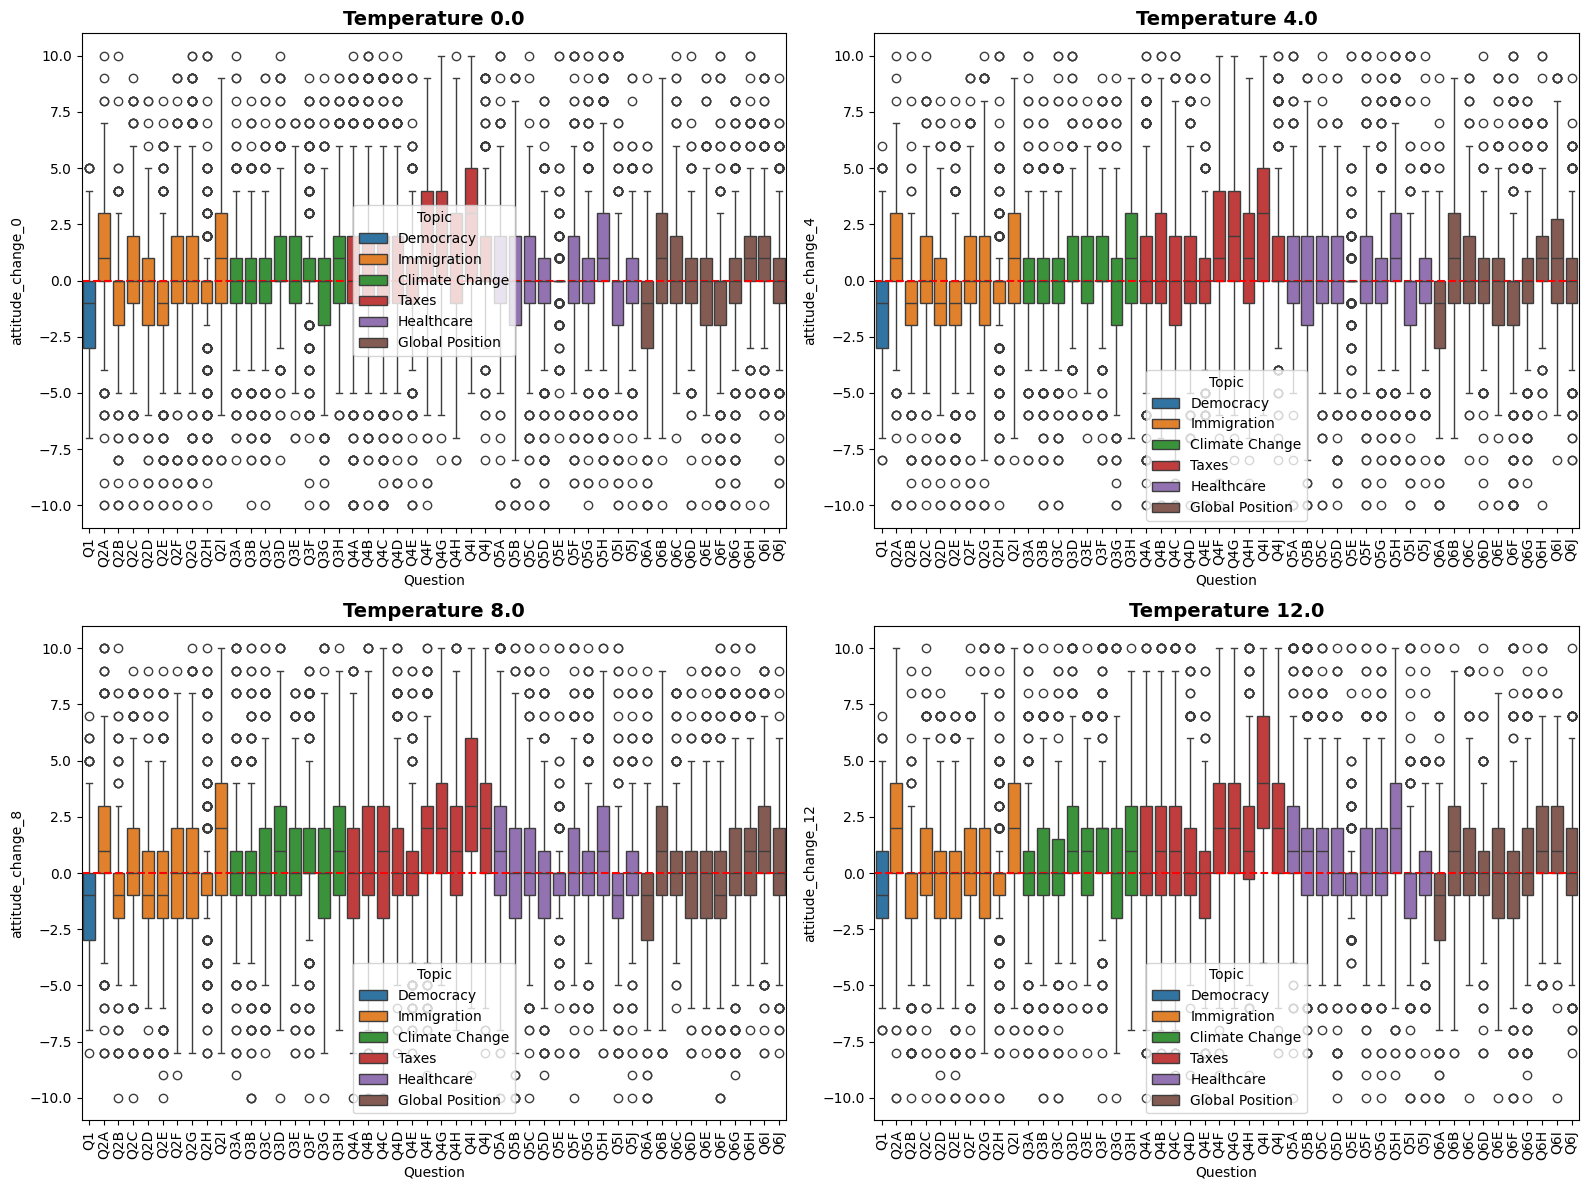

In [10]:
# i want subplots for each temperature
fig, axs = plt.subplots(2, 2, figsize=(16, 12))
sns.boxplot(data=compare_df, x='Question', y='attitude_change_0', hue='Topic', ax=axs[0,0])
axs[0,0].set_title('Temperature 0.0', fontsize=14, fontweight='bold')
axs[0,0].axhline(0, color='red', linestyle='--')
sns.boxplot(data=compare_df, x='Question', y='attitude_change_4', hue='Topic', ax=axs[0,1])
axs[0,1].set_title('Temperature 4.0', fontsize=14, fontweight='bold')
axs[0,1].axhline(0, color='red', linestyle='--')
sns.boxplot(data=compare_df, x='Question', y='attitude_change_8', hue='Topic', ax=axs[1,0])
axs[1,0].set_title('Temperature 8.0', fontsize=14, fontweight='bold')
axs[1,0].axhline(0, color='red', linestyle='--')
sns.boxplot(data=compare_df, x='Question', y='attitude_change_12', hue='Topic', ax=axs[1,1])
axs[1,1].set_title('Temperature 12.0', fontsize=14, fontweight='bold')
axs[1,1].axhline(0, color='red', linestyle='--')
for ax in axs.flat:
    ax.set_xticklabels(ax.get_xticklabels(), rotation=90)
plt.tight_layout()

In [11]:
# for each question and temperature, calculate the mean attitude change and also the standard deviation
summary_stats = []
for question in questions:
    for temp in ['0', '4', '8', '12']:
        col_name = f'temp_{temp}'
        change = compare_df[compare_df['Question'] == question][col_name] - compare_df[compare_df['Question'] == question]['AfterNumber']
        mean_change = change.mean()
        mse_change = (change ** 2).mean()
        rmse_change = np.sqrt(mse_change)
        std_change = change.std()
        summary_stats.append({
            'Question': question,
            'Temperature': str(float(temp)/10),
            'MeanAttitudeChange': mean_change,
            'RMSEAttitudeChange': rmse_change,
            'StdAttitudeChange': std_change
        })
summary_df = pd.DataFrame(summary_stats)

In [12]:
summary_df.head()

,Question,Temperature,MeanAttitudeChange,RMSEAttitudeChange,StdAttitudeChange
0,Q3G,0.0,-0.562780,2.938457,2.887300
1,Q3G,0.4,-0.479821,2.931199,2.894908
2,Q3G,0.8,-0.114350,3.383222,3.385086
3,Q3G,1.2,-0.020179,3.243137,3.246716
4,Q2H,0.0,-0.523810,2.493643,2.440429


/var/folders/qw/dj7vjbyd6kb8q83q6chjb9m00000gn/T/ipykernel_64842/1686169616.py:5: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=summary_df, x='Question', y='MeanAttitudeChange', hue='Temperature', ci=None)


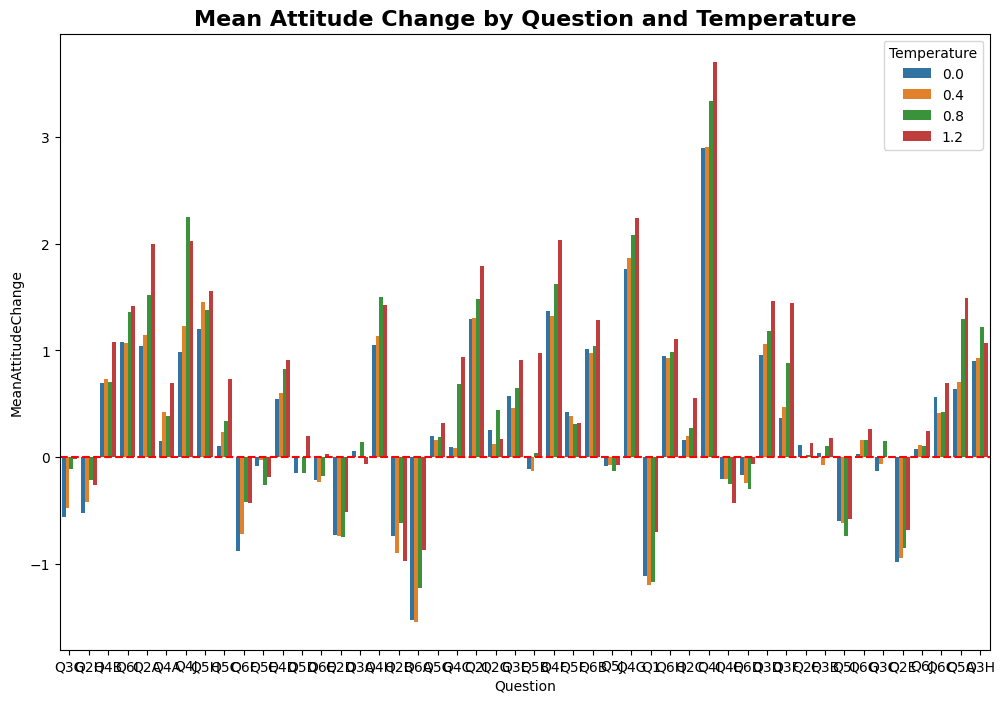

In [13]:
# for each question, plot the mean attitude change with error bars representing the standard deviation
# questions should be on the x axis and mean attitude change on the y axis
# coloured by temperature
plt.figure(figsize=(12, 8))
sns.barplot(data=summary_df, x='Question', y='MeanAttitudeChange', hue='Temperature', ci=None)
plt.title('Mean Attitude Change by Question and Temperature', fontsize=16, fontweight='bold')
plt.axhline(0, color='red', linestyle='--')

In [14]:
# for each question, find the temperature that resulted in the lowest mean attitude change
best_mean_temps = summary_df.loc[summary_df.groupby('Question')['MeanAttitudeChange'].idxmin()]
best_rmse_temps = summary_df.loc[summary_df.groupby('Question')['RMSEAttitudeChange'].idxmin()]

Text(0.5, 1.0, 'Best Temperature by RMSE Attitude Change')

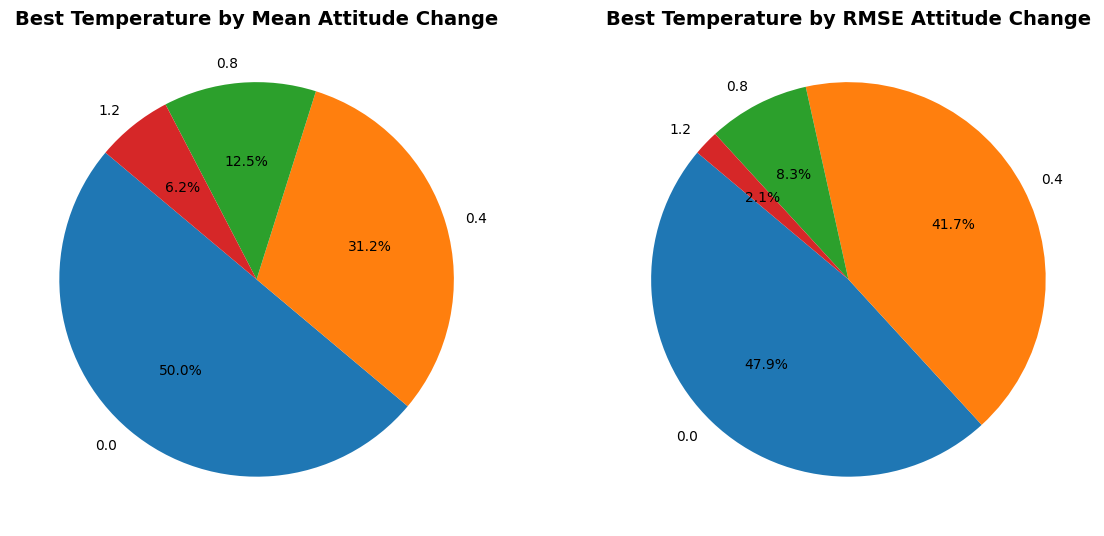

In [15]:
# plot these results as pie charts
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 7))
best_mean_counts = best_mean_temps['Temperature'].value_counts().sort_index()
ax1.pie(best_mean_counts, labels=best_mean_counts.index, autopct='%1.1f%%', startangle=140)
ax1.set_title('Best Temperature by Mean Attitude Change', fontsize=14, fontweight='bold')
best_rmse_counts = best_rmse_temps['Temperature'].value_counts().sort_index()
ax2.pie(best_rmse_counts, labels=best_rmse_counts.index, autopct='%1.1f%%', startangle=140)
ax2.set_title('Best Temperature by RMSE Attitude Change', fontsize=14, fontweight='bold')

In [16]:
# i want to see how good the model is at predicting the after attitude for each temperature
prediction_stats = []
for temp in ['0', '4', '8', '12']:
    col_name = f'temp_{temp}'
    mean = (compare_df[col_name] - compare_df['AfterNumber']).mean()
    mse = np.mean((compare_df[col_name] - compare_df['AfterNumber']) ** 2)
    rmse = np.sqrt(mse)
    prediction_stats.append({
        'Temperature': temp,
        'Mean': mean,
        'MSE': mse,
        'RMSE': rmse
    })

prediction_df = pd.DataFrame(prediction_stats)

In [17]:
prediction_df.head()

,Temperature,Mean,MSE,RMSE
0,0,0.275126,8.050946,2.837419
1,4,0.300989,8.115084,2.848699
2,8,0.459339,9.669979,3.109659
3,12,0.621507,9.717150,3.117234


/var/folders/qw/dj7vjbyd6kb8q83q6chjb9m00000gn/T/ipykernel_64842/1156756816.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


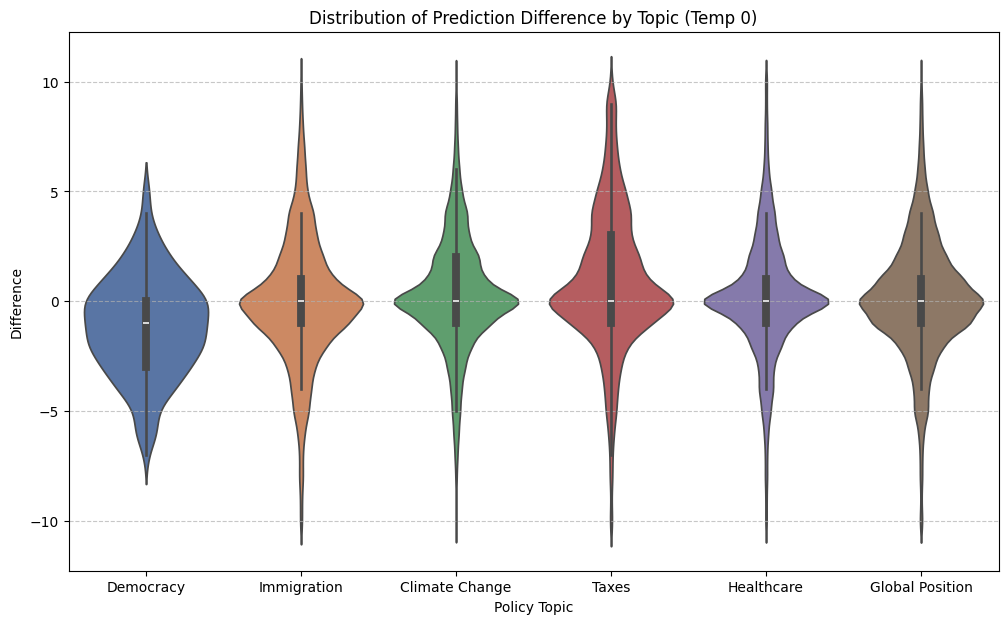

/var/folders/qw/dj7vjbyd6kb8q83q6chjb9m00000gn/T/ipykernel_64842/1156756816.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


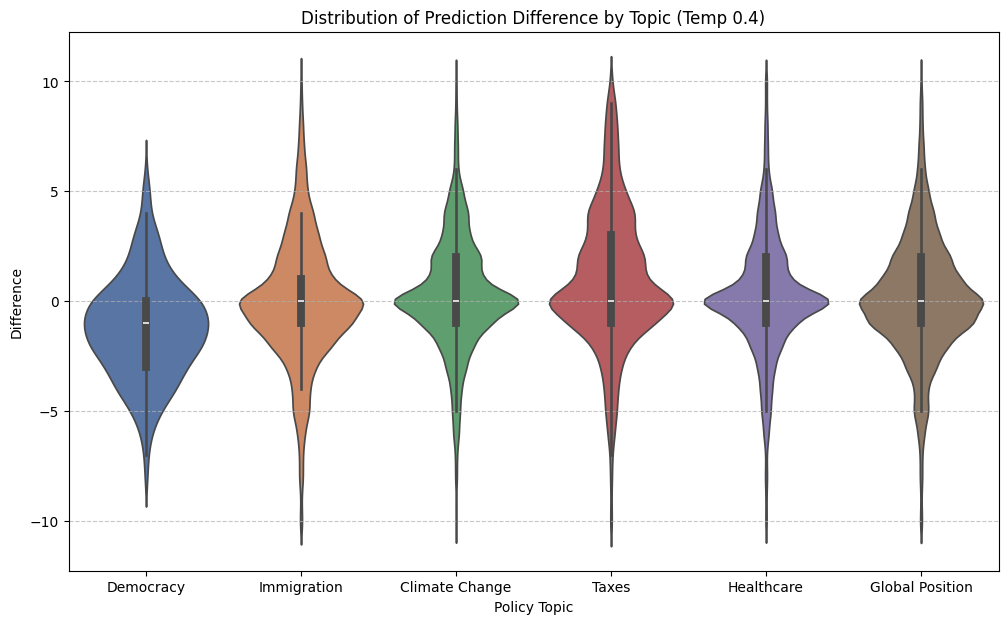

/var/folders/qw/dj7vjbyd6kb8q83q6chjb9m00000gn/T/ipykernel_64842/1156756816.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


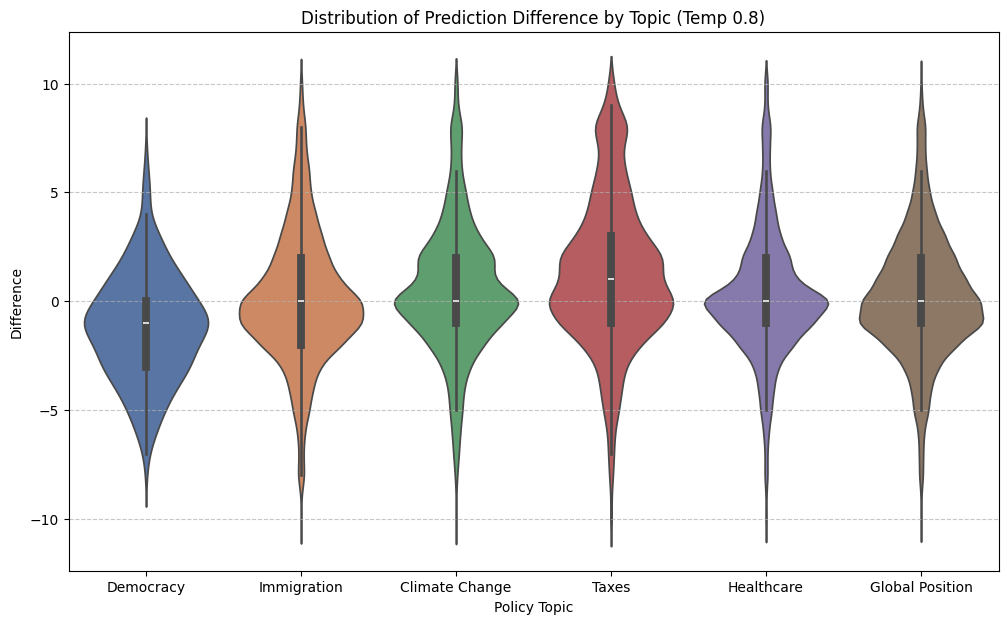

/var/folders/qw/dj7vjbyd6kb8q83q6chjb9m00000gn/T/ipykernel_64842/1156756816.py:52: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


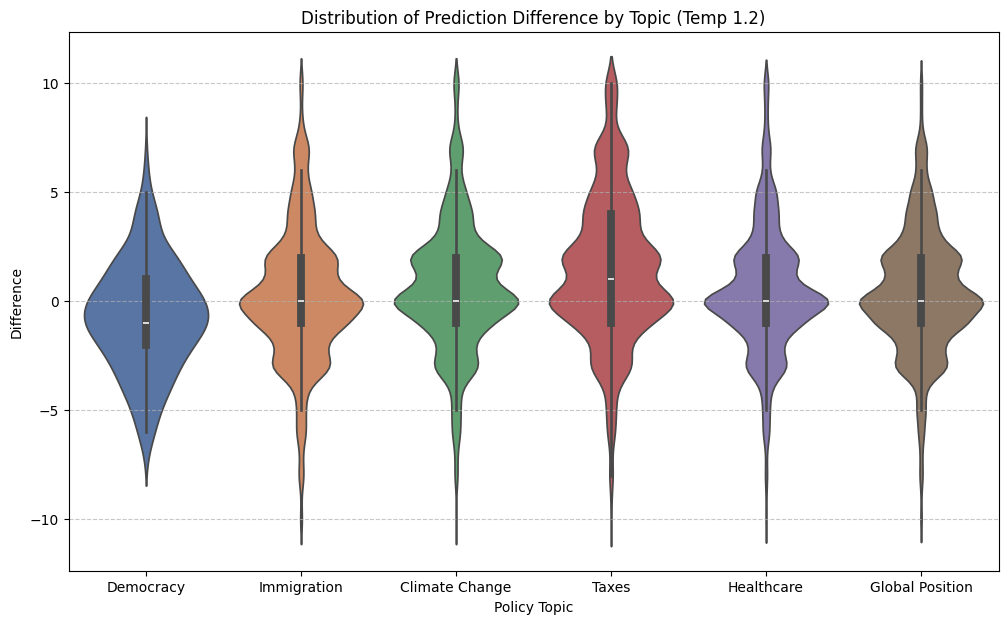

In [18]:
# Assuming your data is loaded into a Pandas DataFrame called 'df'
import seaborn as sns
import matplotlib.pyplot as plt

## do this and compare for each temperature
plt.figure(figsize=(12, 7))
sns.violinplot(
    x='Topic',
    y='attitude_change_0',
    data=compare_df,
    palette='deep'
)
plt.title('Distribution of Prediction Difference by Topic (Temp 0)')
plt.xlabel('Policy Topic')
plt.ylabel('Difference')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


plt.figure(figsize=(12, 7))
# Create the Box Plot
sns.violinplot(
    x='Topic',         # Use Topic as the categorical axis
    y='attitude_change_4',      # Use ABS_DIFF as the continuous distribution axis
    data=compare_df,
    palette='deep'     # Use a distinct color palette
)

plt.title('Distribution of Prediction Difference by Topic (Temp 0.4)')
plt.xlabel('Policy Topic')
plt.ylabel('Difference')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

plt.figure(figsize=(12, 7))
# Create the Box Plot
sns.violinplot(
    x='Topic',         # Use Topic as the categorical axis
    y='attitude_change_8',      # Use ABS_DIFF as the continuous distribution axis
    data=compare_df,
    palette='deep'     # Use a distinct color palette
)

plt.title('Distribution of Prediction Difference by Topic (Temp 0.8)')
plt.xlabel('Policy Topic')
plt.ylabel('Difference')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

plt.figure(figsize=(12, 7))
# Create the Box Plot
sns.violinplot(
    x='Topic',         # Use Topic as the categorical axis
    y='attitude_change_12',      # Use ABS_DIFF as the continuous distribution axis
    data=compare_df,
    palette='deep'     # Use a distinct color palette
)
plt.title('Distribution of Prediction Difference by Topic (Temp 1.2)')
plt.xlabel('Policy Topic')
plt.ylabel('Difference')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


In [19]:
import pandas as pd
import numpy as np
from scipy import stats
import statsmodels.formula.api as smf
from sklearn.metrics import cohen_kappa_score

# df = pd.read_csv("your_data.csv") # Ensure data is loaded

results = []
questions = compare_df['Question'].unique()

for q in questions:
    question_plot_df = compare_df[compare_df['Question'] == q]
    real_data = question_plot_df["AfterNumber"]
    measurements = {}
    for temp in ["temp_0", "temp_4", "temp_8", "temp_12"]:
        sim_data = question_plot_df[temp]  # Change temp_X as needed

        # --- TEST 1: Paired Difference & Distribution ---
        try:
            # exact=False suppresses warnings for ties/zeros in large N
            w_stat, p_wilcox = stats.wilcoxon(real_data, sim_data)
        except ValueError:
            p_wilcox = 1.0

        try:
            kappa = cohen_kappa_score(real_data, sim_data, weights='quadratic')
        except:
            kappa = np.nan
            
        w_dist = stats.wasserstein_distance(real_data, sim_data)
        
        # Simple raw bias (Sim - Real)
        raw_bias = (sim_data - real_data).mean()
        raw_std = (sim_data - real_data).std()
        raw_rmse = np.sqrt(np.mean((sim_data - real_data) ** 2))



        # --- TEST 2: Demographic Alignment (Regression) ---
        real_df = question_plot_df.copy().drop(temp, axis=1)
        real_df.rename(columns={"AfterNumber": "Response"}, inplace=True)
        real_df['Is_Simulated'] = 0
        
        sim_df = question_plot_df.copy().drop("AfterNumber", axis=1)
        sim_df.rename(columns={temp: "Response"}, inplace=True)
        sim_df['Is_Simulated'] = 1
        
        question_regr_df = pd.concat([real_df, sim_df], ignore_index=True)
        
        # Base formula to check for systematic intercept shift (Bias)
        formula = "Response ~ BeforeNumber + C(RACE) + C(GENDER) + C(EDUCATION) + AGE + C(PARTYBEFORE) + Is_Simulated"

        try:
            model = smf.ols(formula, data=question_regr_df).fit(
                cov_type='cluster', 
                cov_kwds={'groups': question_regr_df['ID']}
            )
            sim_coef = model.params['Is_Simulated']
            sim_p_val = model.pvalues['Is_Simulated']
        except Exception as e:
            sim_coef, sim_p_val = np.nan, np.nan
        
        biasStr = temp + "_regression_bias"
        pValStr = temp + "_regression_pval"
        rawBiasStr = temp + "_bias"
        stdStr = temp + "_std"
        rmseStr = temp + "_rmse"
        wassersteinStr = temp + "_wasserstein"
        kappaStr = temp + "_kappa"
        wilcox = temp + "_wilcoxon_pval"

        measurements[rawBiasStr] = raw_bias # positive means simulated is higher
        measurements[stdStr] = raw_std # lower is better
        measurements[rmseStr] = raw_rmse # lower is better
        measurements[biasStr] = sim_coef # positive means simulated is higher
        measurements[pValStr] = sim_p_val # < 0.05 indicates significant bias
        measurements[wassersteinStr] = w_dist # lower is better
        measurements[kappaStr] = kappa # closer to 1 is better
        measurements[wilcox] = p_wilcox # < 0.05 indicates significant difference

    results.append({
        'Question': q,
        **measurements
    })
results_df = pd.DataFrame(results)
print(results_df.head())


  Question  temp_0_bias  temp_0_std  temp_0_rmse  temp_0_regression_bias  \
0       Q1    -1.108163    2.285934     2.538278               -1.108163   
1      Q2A     1.045908    2.719538     2.911194                1.045908   
2      Q2B    -0.738000    2.180565     2.300000               -0.738000   
3      Q2C     0.165657    2.827144     2.829141                0.165657   
4      Q2D    -0.732535    2.440557     2.545788               -0.732535   

   temp_0_regression_pval  temp_0_wasserstein  temp_0_kappa  \
0            1.671329e-26            1.116327      0.348444   
1            1.253619e-17            1.197605      0.565078   
2            5.707208e-14            0.738000      0.456990   
3            1.955284e-01            0.444444      0.500592   
4            2.538320e-11            0.732535      0.469468   

   temp_0_wilcoxon_pval  temp_4_bias  ...  temp_8_kappa  temp_8_wilcoxon_pval  \
0          1.945360e-22    -1.197959  ...      0.268889          5.645913e-22   
1 

In [20]:
model.params

Intercept                                    4.189223
C(RACE)[T.Asian, non-Hispanic]              -0.196306
C(RACE)[T.Black, non-Hispanic]              -0.643503
C(RACE)[T.Hispanic]                         -0.450102
C(RACE)[T.Other, non-Hispanic]               0.482161
C(RACE)[T.White, non-Hispanic]               0.004437
C(GENDER)[T.Male]                           -0.031508
C(EDUCATION)[T.HS graduate or equivalent]    0.080881
C(EDUCATION)[T.No HS diploma]                0.250943
C(EDUCATION)[T.Some college]                -0.049380
C(PARTYBEFORE)[T.Independent]               -0.420337
C(PARTYBEFORE)[T.Republican]                -0.668235
BeforeNumber                                 0.490246
AGE                                          0.002904
Is_Simulated                                 0.243408
dtype: float64

In [21]:
# for each question, find the tempterature with the lowest wasserstein distance
best_wasserstein_temps = []
for index, row in results_df.iterrows():
    question = row['Question']
    wasserstein_values = {
        '0': row['temp_0_wasserstein'],
        '4': row['temp_4_wasserstein'],
        '8': row['temp_8_wasserstein'],
        '12': row['temp_12_wasserstein'],
    }
    best_temp = min(wasserstein_values, key=wasserstein_values.get)
    best_wasserstein_temps.append({
        'Question': question,
        'BestTemperature': best_temp,
        'WassersteinDistance': wasserstein_values[best_temp]
    })
best_wasserstein_df = pd.DataFrame(best_wasserstein_temps)
best_wasserstein_df.head()

,Question,BestTemperature,WassersteinDistance
0,Q1,12,0.842857
1,Q2A,0,1.197605
2,Q2B,8,0.622000
3,Q2C,4,0.412121
4,Q2D,12,0.724551


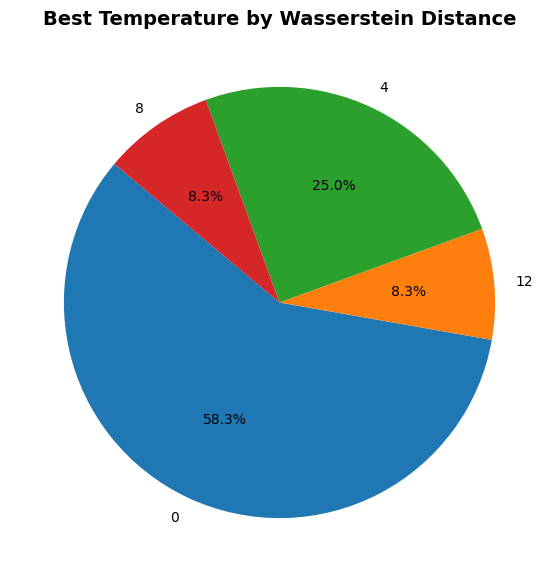

In [22]:
# pie chart of best temperatures by wasserstein distance
best_wasserstein_counts = best_wasserstein_df['BestTemperature'].value_counts().sort_index()
plt.figure(figsize=(7, 7))
plt.pie(best_wasserstein_counts, labels=best_wasserstein_counts.index, autopct='%1.1f%%', startangle=140)
plt.title('Best Temperature by Wasserstein Distance', fontsize=14, fontweight='bold')
plt.show()

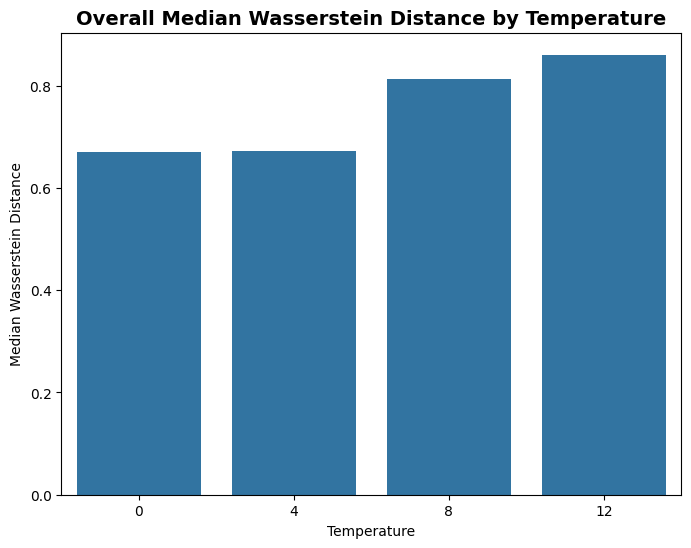

In [23]:
# for each temperature, calculate the overall median wasserstein distance
overall_wasserstein = {}
for temp in ['0', '4', '8', '12']:
    col_name = f'temp_{temp}_wasserstein'
    overall_wasserstein[temp] = results_df[col_name].median()
overall_wasserstein
# plot overall median wasserstein distances as a bar chart
plt.figure(figsize=(8, 6))
sns.barplot(x=list(overall_wasserstein.keys()), y=list(overall_wasserstein.values()))
plt.title('Overall Median Wasserstein Distance by Temperature', fontsize=14, fontweight='bold')
plt.xlabel('Temperature')
plt.ylabel('Median Wasserstein Distance')
plt.show()

In [24]:
sumdf = results_df.describe().reset_index()

In [25]:
results_df.to_csv("results/full_run_4/attitude_simulation_evaluation_by_question.csv", index=False)

In [26]:
results_df[['temp_0_regression_bias', 'temp_4_regression_bias', 'temp_8_regression_bias']].median()

temp_0_regression_bias    0.135786
temp_4_regression_bias    0.162575
temp_8_regression_bias    0.296279
dtype: float64

In [27]:
results_df[['temp_0_bias', 'temp_4_bias', 'temp_8_bias']].median()

temp_0_bias    0.135786
temp_4_bias    0.162575
temp_8_bias    0.296279
dtype: float64

In [28]:
sumdf

,index,temp_0_bias,temp_0_std,temp_0_rmse,temp_0_regression_bias,temp_0_regression_pval,temp_0_wasserstein,temp_0_kappa,temp_0_wilcoxon_pval,temp_4_bias,...,temp_8_kappa,temp_8_wilcoxon_pval,temp_12_bias,temp_12_std,temp_12_rmse,temp_12_regression_bias,temp_12_regression_pval,temp_12_wasserstein,temp_12_kappa,temp_12_wilcoxon_pval
0,count,48.000000,48.000000,48.000000,48.000000,4.800000e+01,48.000000,48.000000,4.800000e+01,48.000000,...,48.000000,4.800000e+01,48.000000,48.000000,48.000000,48.000000,4.800000e+01,48.000000,48.000000,4.800000e+01
1,mean,0.267217,2.688787,2.803931,0.267217,1.360802e-01,0.751176,0.525485,1.280661e-01,0.292491,...,0.391535,1.272621e-01,0.615805,2.886192,3.073834,0.615805,1.148493e-01,1.035382,0.418387,1.174540e-01
2,std,0.810586,0.400325,0.478031,0.810586,2.199292e-01,0.511216,0.120530,2.108312e-01,0.831542,...,0.103291,2.556616e-01,0.962557,0.385921,0.549953,0.962557,2.547604e-01,0.625544,0.109229,2.631337e-01
3,min,-1.525000,1.409289,1.410072,-1.525000,3.465348e-75,0.159844,0.200031,2.614566e-46,-1.540000,...,0.141169,1.405203e-52,-0.974000,1.617033,1.625815,-0.974000,7.313336e-129,0.311891,0.130144,6.656111e-60
4,25%,-0.154528,2.440525,2.534499,-0.154528,1.104311e-15,0.351085,0.452660,1.588725e-15,-0.146320,...,0.328910,7.529129e-17,-0.058854,2.682853,2.726603,-0.058854,1.325394e-21,0.624536,0.358997,6.918920e-20
5,50%,0.135786,2.681817,2.755908,0.135786,1.597807e-06,0.669899,0.528431,2.025198e-06,0.162575,...,0.388352,1.083653e-05,0.438194,2.852392,2.965926,0.438194,4.507025e-08,0.860327,0.424131,1.192755e-07
6,75%,0.914133,2.891770,3.027308,0.914133,2.168967e-01,0.995390,0.609985,1.473007e-01,0.928497,...,0.453977,8.785309e-02,1.318132,3.147909,3.454069,1.318132,3.057835e-02,1.391416,0.481088,3.742777e-02
7,max,2.891775,3.664611,4.431782,2.891775,8.282877e-01,2.891775,0.801862,6.631690e-01,2.909091,...,0.659433,9.741886e-01,3.703463,4.002887,4.938803,3.703463,9.731635e-01,3.703463,0.656591,9.680874e-01


In [29]:
sumdf[['index', 'temp_0_wasserstein', 'temp_4_wasserstein', 'temp_8_wasserstein', 'temp_12_wasserstein']]

,index,temp_0_wasserstein,temp_4_wasserstein,temp_8_wasserstein,temp_12_wasserstein
0,count,48.000000,48.000000,48.000000,48.000000
1,mean,0.751176,0.786547,0.971006,1.035382
2,std,0.511216,0.522811,0.590030,0.625544
3,min,0.159844,0.128655,0.249476,0.311891
4,25%,0.351085,0.372882,0.538295,0.624536
5,50%,0.669899,0.672372,0.813693,0.860327
6,75%,0.995390,1.072666,1.252687,1.391416
7,max,2.891775,2.909091,3.337662,3.703463


In [30]:
sumdf[['index', 'temp_0_kappa', 'temp_4_kappa', 'temp_8_kappa', 'temp_12_kappa']]

,index,temp_0_kappa,temp_4_kappa,temp_8_kappa,temp_12_kappa
0,count,48.000000,48.000000,48.000000,48.000000
1,mean,0.525485,0.505435,0.391535,0.418387
2,std,0.120530,0.121371,0.103291,0.109229
3,min,0.200031,0.177754,0.141169,0.130144
4,25%,0.452660,0.434892,0.328910,0.358997
5,50%,0.528431,0.505659,0.388352,0.424131
6,75%,0.609985,0.570377,0.453977,0.481088
7,max,0.801862,0.786684,0.659433,0.656591


In [31]:
sumdf[['index', 'temp_0_bias', 'temp_4_bias', 'temp_8_bias', 'temp_12_bias']]

,index,temp_0_bias,temp_4_bias,temp_8_bias,temp_12_bias
0,count,48.000000,48.000000,48.000000,48.000000
1,mean,0.267217,0.292491,0.452638,0.615805
2,std,0.810586,0.831542,0.919630,0.962557
3,min,-1.525000,-1.540000,-1.227500,-0.974000
4,25%,-0.154528,-0.146320,-0.156445,-0.058854
5,50%,0.135786,0.162575,0.296279,0.438194
6,75%,0.914133,0.928497,1.077593,1.318132
7,max,2.891775,2.909091,3.333333,3.703463


In [32]:
sumdf[['index', 'temp_0_wilcoxon_pval', 'temp_4_wilcoxon_pval', 'temp_8_wilcoxon_pval', 'temp_12_wilcoxon_pval']]

,index,temp_0_wilcoxon_pval,temp_4_wilcoxon_pval,temp_8_wilcoxon_pval,temp_12_wilcoxon_pval
0,count,4.800000e+01,4.800000e+01,4.800000e+01,4.800000e+01
1,mean,1.280661e-01,1.547380e-01,1.272621e-01,1.174540e-01
2,std,2.108312e-01,2.768736e-01,2.556616e-01,2.631337e-01
3,min,2.614566e-46,1.033291e-47,1.405203e-52,6.656111e-60
4,25%,1.588725e-15,6.172352e-18,7.529129e-17,6.918920e-20
5,50%,2.025198e-06,9.572480e-06,1.083653e-05,1.192755e-07
6,75%,1.473007e-01,1.696939e-01,8.785309e-02,3.742777e-02
7,max,6.631690e-01,9.930846e-01,9.741886e-01,9.680874e-01


In [33]:
compare_df['temp_0_len'] = compare_df['temp_0_arguments'].apply(len)
compare_df['temp_4_len'] = compare_df['temp_4_arguments'].apply(len)
compare_df['temp_8_len'] = compare_df['temp_8_arguments'].apply(len)
compare_df['temp_12_len'] = compare_df['temp_12_arguments'].apply(len)

In [34]:
compare_df[['temp_0_len', 'temp_4_len', 'temp_8_len', 'temp_12_len']].describe()

,temp_0_len,temp_4_len,temp_8_len,temp_12_len
count,23044.000000,23044.000000,23044.000000,23044.000000
mean,807.296780,766.581670,937.436035,937.436035
std,272.194384,267.672466,207.857069,207.857069
min,219.000000,207.000000,5.000000,5.000000
25%,526.000000,513.000000,903.000000,903.000000
50%,973.000000,739.000000,1016.000000,1016.000000
75%,1048.000000,1041.000000,1069.000000,1069.000000
max,1203.000000,2498.000000,2918.000000,2918.000000


In [35]:
# filter for questions when regression pval > 0.05 for temp 0 4 8 
filtered_results_df = results_df[
    (results_df['temp_0_regression_pval'] > 0.05) |
    (results_df['temp_4_regression_pval'] > 0.05) |
    (results_df['temp_8_regression_pval'] > 0.05) |
    (results_df['temp_12_regression_pval'] > 0.05)
]
filtered_results_df

,Question,temp_0_bias,temp_0_std,temp_0_rmse,temp_0_regression_bias,temp_0_regression_pval,temp_0_wasserstein,temp_0_kappa,temp_0_wilcoxon_pval,temp_4_bias,...,temp_8_kappa,temp_8_wilcoxon_pval,temp_12_bias,temp_12_std,temp_12_rmse,temp_12_regression_bias,temp_12_regression_pval,temp_12_wasserstein,temp_12_kappa,temp_12_wilcoxon_pval
3,Q2C,0.165657,2.827144,2.829141,0.165657,0.195528,0.444444,0.500592,1.358295e-01,0.202020,...,0.327302,8.500146e-02,0.555556,2.728698,2.781977,0.555556,6.873180e-06,0.608081,0.518701,5.180121e-06
6,Q2F,0.115124,2.908534,2.907529,0.115124,0.408533,0.444695,0.397095,3.517526e-01,0.006772,...,0.340214,8.673464e-01,0.130926,2.900463,2.900144,0.130926,3.459201e-01,0.862302,0.347101,4.457191e-01
7,Q2G,0.259494,3.386043,3.392409,0.259494,0.097699,0.748945,0.293333,1.568988e-01,0.122363,...,0.141169,5.137154e-02,0.170886,3.441188,3.441801,0.170886,2.832117e-01,1.002110,0.215121,7.552111e-01
8,Q2H,-0.523810,2.440429,2.493643,-0.523810,0.000002,0.523810,0.675394,2.677419e-07,-0.420635,...,0.527464,1.967395e-03,-0.263889,2.639320,2.649873,-0.263889,2.581590e-02,0.474206,0.564850,3.191853e-03
10,Q3A,0.061002,2.174832,2.173318,0.061002,0.550956,0.204793,0.801862,6.378007e-01,0.000000,...,0.659433,7.241813e-01,-0.058824,2.748327,2.745962,-0.058824,6.490815e-01,0.620915,0.656591,3.087236e-01
11,Q3B,0.036638,2.419493,2.417162,0.036638,0.746155,0.312500,0.741842,4.310164e-01,-0.075431,...,0.612259,4.890799e-01,0.183190,2.838880,2.841730,0.183190,1.677537e-01,0.428879,0.608110,1.619394e-01
12,Q3C,-0.130435,2.556735,2.557415,-0.130435,0.265694,0.337474,0.633758,4.432213e-01,-0.066253,...,0.453409,4.659579e-01,0.004141,2.685442,2.682664,0.004141,9.731635e-01,0.401656,0.585229,9.393365e-01
16,Q3G,-0.562780,2.887300,2.938457,-0.562780,0.000044,0.594170,0.551157,7.971730e-05,-0.479821,...,0.393445,3.366324e-01,-0.020179,3.246716,3.243137,-0.020179,8.963890e-01,0.755605,0.451479,9.680874e-01
18,Q4A,0.156448,3.480096,3.479933,0.156448,0.331827,0.350951,0.409749,2.002059e-01,0.424947,...,0.279991,3.537219e-02,0.697674,3.411647,3.478718,0.697674,1.012597e-05,0.858351,0.360290,1.133372e-05
20,Q4C,0.092342,3.664611,3.661647,0.092342,0.598363,0.362613,0.436546,5.685914e-01,0.085586,...,0.259567,2.406318e-04,0.936937,4.002887,4.106685,0.936937,9.931813e-07,0.981982,0.287312,1.455893e-06


In [36]:
# filter for questions when regression pval < 0.05 for all temps with a loop and extract the questions from each
filtered_results_df_all = results_df.copy()
bestTemps = {}
for temp in ['0', '4', '8', '12']:
    pval_col = f'temp_{temp}_regression_pval'
    questionsList = filtered_results_df_all[filtered_results_df_all[pval_col] > 0.05]["Question"]
    bestTemps[temp] = questionsList.tolist()


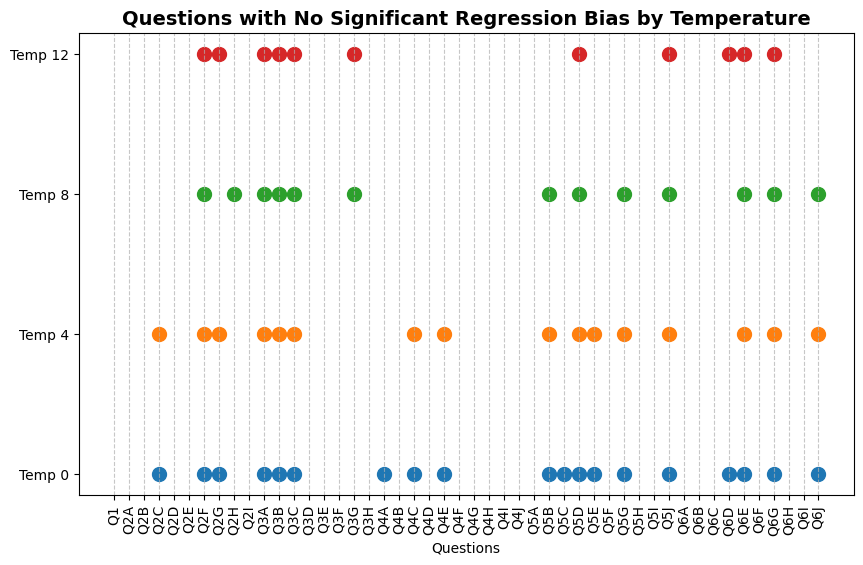

In [37]:
# show in graph which questions had no significant bias for each temperature
plt.figure(figsize=(10, 6))
plt.scatter(results_df['Question'], [0]*len(results_df), color='gray', alpha=0.0, label='All Questions', s=50)
for temp, questionsList in bestTemps.items():
    y = [int(temp)] * len(questionsList)
    plt.scatter(questionsList, y, label=f'Temp {temp}', s=100)
plt.yticks([0, 4, 8, 12], ['Temp 0', 'Temp 4', 'Temp 8', 'Temp 12'])
plt.xlabel('Questions')
plt.title('Questions with No Significant Regression Bias by Temperature', fontsize=14, fontweight='bold')
plt.xticks(rotation=90)
plt.grid(axis='x', linestyle='--', alpha=0.7)

In [38]:
# calculate the sum of absolute differences for each temperature when grouped by group number
for temp in ['0', '4', '8', '12']:
    col_name = f'temp_{temp}'
    compare_df[f'abs_diff_{temp}'] = (compare_df[col_name] - compare_df['AfterNumber']).abs()

# group by question and group then calculate the median and std absolute difference for each temperature and group size
summary_group_stats = []
for question in questions:
    for group in groups:
        group_df = compare_df[(compare_df['Question'] == question) & (compare_df['GROUP'] == group)]
        group_size = len(group_df)
        for temp in ['0', '4', '8', '12']:
            col_name = f'abs_diff_{temp}'
            median_diff = group_df[col_name].median()
            mean_diff = group_df[col_name].mean()
            std_diff = group_df[col_name].std()
            avg_diff = group_df[col_name].sum()/group_size
            summary_group_stats.append({
                'Question': question,
                'Group': group,
                'Temperature': str(float(temp)/10),
                'MedianAbsDiff': median_diff,
                'MeanAbsDiff': mean_diff,
                'StdAbsDiff': std_diff
            })
summary_group_df = pd.DataFrame(summary_group_stats)

In [39]:
summary_group_df.head()

,Question,Group,Temperature,MedianAbsDiff,MeanAbsDiff,StdAbsDiff
0,Q1,1,0.0,2.0,1.928571,1.268814
1,Q1,1,0.4,2.0,1.928571,1.206666
2,Q1,1,0.8,2.5,2.571429,1.342460
3,Q1,1,1.2,2.0,1.642857,1.215739
4,Q1,2,0.0,2.5,2.625000,1.784190


In [40]:
# for each group, count the amount of questions where each temperature had the lowest mean absolute difference
best_group_temps = []
for group in groups:
    group_subset = summary_group_df[summary_group_df['Group'] == group]
    best_temps = group_subset.loc[group_subset.groupby('Question')['MeanAbsDiff'].idxmin()]
    temp_counts = best_temps['Temperature'].value_counts().to_dict()
    for temp in ['0.0', '0.4', '0.8', '1.2']:
        count = temp_counts.get(temp, 0)
        best_group_temps.append({
            'Group': group,
            'Temperature': temp,
            'Count': count
        })

best_group_temps = pd.DataFrame(best_group_temps)

In [41]:
# for each question, decide if temp 0, 4, 8 or 12 was first second third or fourth best based on lowest mean absolute difference
ranked_temps = []
for question in questions:
    question_subset = summary_group_df[summary_group_df['Question'] == question]
    ranked = question_subset.groupby('Temperature')['MeanAbsDiff'].mean().sort_values().reset_index()
    ranked['Rank'] = ranked.index + 1
    for index, row in ranked.iterrows():
        ranked_temps.append({
            'Question': question,
            'Temperature': row['Temperature'],
            'Rank': row['Rank']
        })
ranked_temps_df = pd.DataFrame(ranked_temps)

In [42]:
ranked_temps_df.head()

,Question,Temperature,Rank
0,Q1,0.0,1
1,Q1,1.2,2
2,Q1,0.4,3
3,Q1,0.8,4
4,Q2A,0.0,1


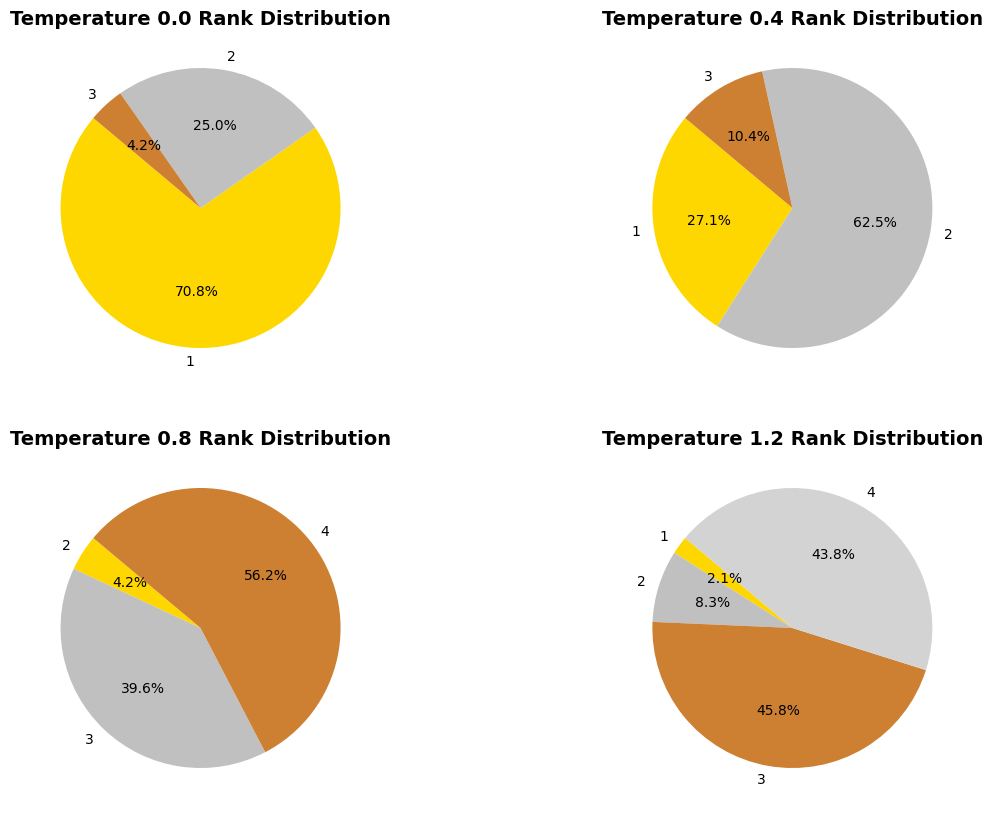

In [43]:
# plot a pie chart for each temperature showing how many times it was ranked in each place

# i want 1st to be gold, 2nd silver, 3rd bronze, 4th grey
colors = ['#FFD700', '#C0C0C0', '#CD7F32', '#D3D3D3']
fig, axs = plt.subplots(2, 2, figsize=(14, 10))
for i, temp in enumerate(['0.0', '0.4', '0.8', '1.2']):
    # colours should be assigned based on a dictionary
    ax = axs[i//2, i%2]
    temp_subset = ranked_temps_df[ranked_temps_df['Temperature'] == temp]
    rank_counts = temp_subset['Rank'].value_counts().sort_index()
    ax.pie(rank_counts, labels=rank_counts.index, autopct='%1.1f%%', startangle=140, colors=colors)
    ax.set_title(f'Temperature {temp} Rank Distribution', fontsize=14, fontweight='bold')